# BAG correlates explorer

Assembles, in one wide table:

- **Global BAG** (raw + Cole-corrected) for every session, from the current *production* `stacked` model's stored `predictions` rows (real out-of-fold values, not the full-data refit).
- **Regional BAG** (raw + Cole-corrected, one corrector per region), one column per `atlas__region`, predicted directly from the production artifact's own fitted per-region base estimators — no retraining. In-sample for sessions the model was trained on, out-of-sample for any added since. Raw is what actually feeds the meta-learner; corrected is what region-level analysis below uses.
- **Metadata**: SNBB + legacy demographics/session context (lab/protocol/study/group/scan_tag/scan_date, not just age/sex), questionnaire responses (SNBB only — hundreds of columns: PHQ9/GAD7/PCL-5/OASIS/BIG5/POMS/SCS/... plus lifestyle/environment/health fields), physiological measurements (hand grip, seca anthropometrics), and CAT12 QC (SIQR).

Then a generic `explore(feature)` helper: pass any metadata column name, get its correlation with global BAG plus a ranked bar chart of which brain regions correlate most strongly — numeric features use Pearson/Spearman, categorical features use group means + one-way ANOVA.

**Real data only — do not commit outputs.** `nbstripout` should already be wired via pre-commit; double check before pushing.

In [ ]:
import json

import cloudpickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from bagpipe.core.config import get_path
from bagpipe.db.base import get_engine
from bagpipe.models.tabular import build_region_matrix

# bagpipe's own tables (features, predictions, ...) live in the same SQLite
# file as brainlink's (participant, session, questionnaire_response, ...) —
# one engine covers both.
engine = get_engine()

## 1. Production model config — read live, not hardcoded

In [ ]:
reg_row = pd.read_sql(
    "select * from models_registry where name = 'stacked' and stage = 'production' "
    "order by trained_at desc limit 1",
    engine,
).iloc[0]
model_id = int(reg_row["model_id"])
model_config = json.loads(reg_row["config_json"])
print(f"production model_id={model_id} version={reg_row['version']} trained_at={reg_row['trained_at']}")
model_config

production model_id=28 version=v3 trained_at=2026-08-31 04:42:25


{'datasets_dir': 'outputs/datasets_v26',
 'features': {'metrics': ['vol_gm', 'vol_wm', 'vol_csf']},
 'stacker': {'base_estimator': {'type': 'ridgecv_interactions'},
  'meta_estimator': {'type': 'ridgecv'},
  'outer_cv': 5,
  'inner_cv': 3,
  'n_jobs': -1,
  'random_state': 0},
 'bias_correction': 'cole',
 'n_splits': 5,
 'mlflow': {'experiment': 'bagpipe-cat12v26',
  'run_name': 'stacked-ridgecvinteractions-ridgecv-cole-v26'}}

## 2. Regional BAG — from the production artifact, no retraining or fitting here

`predictions` only stores the global (meta-learner) BAG. But the saved artifact's
`region_estimators_` (fit once, at promotion time) can predict per-region age directly
on the current region matrix — no need to refit `RegionalStackingRegressor` here.

Two variants, both precomputed and stored on the artifact at promotion time
(`bagpipe.models.promote.promote` → `bagpipe.models.bias_correction.fit_region_correctors`):
**raw** (`region_estimators_` — untouched, what actually feeds the meta-learner) and
**Cole-corrected** (`region_correctors_`, one corrector per region). This notebook only
calls `.predict()`/`.transform()` on what's already fit — no correction is fit here.
Corrected is what region-level analysis (`explore()`, the brain-surface plots) should
use — raw regional predictions carry the same age-dependent bias the Cole correction
exists to remove.

In [ ]:
from pathlib import Path

from bagpipe.core.config import REPO_ROOT

feature_cfg = model_config.get("features", {})
datasets_dir = (
    REPO_ROOT / model_config["datasets_dir"] if model_config.get("datasets_dir") else get_path("datasets_dir")
)

X, y, groups, region_columns, session_ids = build_region_matrix(
    datasets_dir, metrics=feature_cfg.get("metrics"), atlases=feature_cfg.get("atlases")
)
print(f"{len(y)} sessions, {len(region_columns)} region/metric columns")

1629 sessions, 1296 region/metric columns


In [ ]:
with open(reg_row["artifact_path"], "rb") as f:
    production_model = cloudpickle.load(f)  # TIVSexAdjustedRegressor wrapping a fitted RegionalStackingRegressor

region_x, tiv, sex = X[:, :-2], X[:, -2], X[:, -1]
residuals = production_model.adjuster_.transform(region_x, tiv, sex)  # same TIV/sex adjustment used at training

stacker = production_model.model_
if not hasattr(stacker, "region_correctors_"):
    raise RuntimeError(
        f"model_id={model_id} version={reg_row['version']!r} predates per-region Cole correction "
        "(bagpipe.models.bias_correction.fit_region_correctors) — re-promote to get region_correctors_."
    )
region_names = stacker.region_names_
region_pred_age = np.column_stack(
    [
        stacker.region_estimators_[rname].predict(residuals[:, stacker.region_columns_[rname]])
        for rname in region_names
    ]
)
region_pred_age_corrected = np.column_stack(
    [stacker.region_correctors_[rname].transform(region_pred_age[:, i]) for i, rname in enumerate(region_names)]
)
# In-sample for sessions the model was trained on, genuinely out-of-sample for any session added
# to the cohort since promotion — not a leak-free CV estimate like the global BAG below.
regional_bag_raw = region_pred_age - y[:, None]
regional_bag_corrected = region_pred_age_corrected - y[:, None]

regional_bag_df = pd.DataFrame(regional_bag_raw, columns=[f"region_bag_raw__{r}" for r in region_names])
regional_bag_df.insert(0, "session_id", session_ids)
regional_bag_df.insert(0, "subject_key", groups)

regional_bag_corrected_df = pd.DataFrame(
    regional_bag_corrected, columns=[f"region_bag_corrected__{r}" for r in region_names]
)
regional_bag_corrected_df.insert(0, "session_id", session_ids)
regional_bag_corrected_df.insert(0, "subject_key", groups)

regional_bag_df = regional_bag_df.merge(regional_bag_corrected_df, on=["subject_key", "session_id"])
regional_bag_df.shape

(1629, 866)

## 3. Global BAG — real held-out predictions from `predictions`

In [ ]:
global_bag_df = pd.read_sql(
    "select subject_key, session_id, age_true, bag_raw as global_bag_raw, "
    "bag_corrected as global_bag_corrected from predictions where model_id = :mid",
    engine,
    params={"mid": model_id},
)
global_bag_df.shape

(1532, 5)

## 4. Metadata — everything we can get our hands on

One row per (subject_key, session_id). SNBB (`uid`/`session_id`) and legacy (12-digit id used as both) cohorts are unioned; questionnaire and physiological data only exist for SNBB.

In [ ]:
# SNBB demographics + session context — every non-path, non-PII column on session/demographics,
# not just age/sex, so protocol/study/group_label/scan_tag etc. are explorable too.
snbb_demo = pd.read_sql(
    """
    select s.uid as subject_key, s.session_id, s.subject_code, s.lab, s.protocol, s.study,
           s.group_label, s.scan_tag, s.scan_number, s.scan_date,
           d.age_at_scan as age, d.sex, d.weight_kg, d.height_m, d.dominant_hand
    from session s
    left join demographics d on d.session_id = s.session_id
    where s.uid is not null
    """,
    engine,
)

# Legacy demographics (bagpipe-owned table) — every column LegacyParticipant carries (PII columns
# from the source sheet were never ingested in the first place, see its docstring).
legacy_demo = pd.read_sql(
    """
    select subject_id as subject_key, subject_id as session_id, subject_id as subject_code,
           lab, study, group_label, scan_tag, scan_date, age_at_scan as age, gender as sex,
           weight, height
    from legacy_participant
    """,
    engine,
)

demo = pd.concat([snbb_demo, legacy_demo], ignore_index=True)
demo.shape

(17435, 17)

In [ ]:
# Questionnaire responses (SNBB only, keyed by subject_code): each row is one wide JSON blob,
# a subject can have several partial rows (different questionnaire_version passes) — merge them
# per subject, later (by ingested_at) values winning but not clobbering fields only present earlier.
qresp = pd.read_sql(
    "select subject_code, data, ingested_at from questionnaire_response order by subject_code, ingested_at",
    engine,
)

merged = {}
for subject_code, group in qresp.groupby("subject_code"):
    d = {}
    for blob in group["data"]:
        d.update(json.loads(blob))
    merged[subject_code] = d

questionnaire_wide = pd.DataFrame.from_dict(merged, orient="index").reset_index(names="subject_code")
questionnaire_wide.columns = [
    c if c == "subject_code" else f"q__{c}" for c in questionnaire_wide.columns
]
questionnaire_wide.shape

(4376, 181)

In [ ]:
# Physiological measurements (SNBB only, keyed by uid): hand_grip + seca (anthropometrics),
# each instrument's own JSON blob — take the reading closest to each subject's scan(s), one row
# per uid per instrument, prefixed by instrument to avoid key collisions.
physio = pd.read_sql(
    "select instrument, uid, data from physiological_measurement where uid is not null",
    engine,
)

physio_wide = None
for instrument, group in physio.groupby("instrument"):
    rows = {}
    for uid, blob in zip(group["uid"], group["data"]):
        rows.setdefault(uid, {}).update(json.loads(blob))
    df = pd.DataFrame.from_dict(rows, orient="index").reset_index(names="subject_key")
    df.columns = [c if c == "subject_key" else f"phys__{instrument}__{c}" for c in df.columns]
    physio_wide = df if physio_wide is None else physio_wide.merge(df, on="subject_key", how="outer")

physio_wide.shape if physio_wide is not None else None

(1676, 323)

In [ ]:
# CAT12 QC (SIQR grade etc.) — covariate worth checking BAG correlations against directly.
# A session can have QC rows from more than one reprocessing (source='cat12' and 'cat12_v26'),
# which would silently fan out the merge below (confirmed: e.g. session 200109071247 has 2 rows) —
# keep only the most recently ingested row per session.
qc = pd.read_sql(
    "select subject_key, session_id, siqr_pct, siqr_grade, ncr, icr, res_rms_mm, contrast, "
    "gmv_tiv_pct, vol_abs_wmh, vol_rel_wmh, ingested_at from cat12_quality order by ingested_at",
    engine,
)
qc = qc.drop_duplicates(subset=["subject_key", "session_id"], keep="last").drop(columns=["ingested_at"])
qc.columns = [c if c in ("subject_key", "session_id") else f"qc__{c}" for c in qc.columns]
qc.shape

(5797, 11)

In [ ]:
metadata = demo.merge(questionnaire_wide, on="subject_code", how="left")
metadata = metadata.merge(physio_wide, on="subject_key", how="left")
metadata = metadata.merge(qc, on=["subject_key", "session_id"], how="left")
metadata.shape

(17435, 528)

## 5. Master table — global BAG + regional BAG + metadata

In [ ]:
master = global_bag_df.merge(regional_bag_df, on=["subject_key", "session_id"], how="inner")
master = master.merge(metadata, on=["subject_key", "session_id"], how="left")

# Region-level analysis (explore()'s ranking, the brain-surface plots) uses the corrected columns —
# raw regional BAG carries the same age-dependent bias the Cole correction exists to remove.
REGION_COLS_RAW = [c for c in master.columns if c.startswith("region_bag_raw__")]
REGION_COLS = [c for c in master.columns if c.startswith("region_bag_corrected__")]
META_COLS = [c for c in master.columns if c not in REGION_COLS and c not in REGION_COLS_RAW and c not in ("subject_key", "session_id", "age_true", "global_bag_raw", "global_bag_corrected")]
print(f"{len(master)} sessions, {len(REGION_COLS)} regions, {len(META_COLS)} metadata columns")
master.head()

1532 sessions, 432 regions, 526 metadata columns


,subject_key,session_id,age_true,global_bag_raw,global_bag_corrected,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_Cing_1,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_Cing_2,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_OFC_1,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_PFCl_1,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_PFCl_2,...,phys__seca__Scan time (2),qc__siqr_pct,qc__siqr_grade,qc__ncr,qc__icr,qc__res_rms_mm,qc__contrast,qc__gmv_tiv_pct,qc__vol_abs_wmh,qc__vol_rel_wmh
0,200110171735,200110171735,76.00,12.696930,33.309955,-24.095758,-38.240367,-25.156177,3.745504,-3.893197,...,NaN,75.69,C,0.055688,0.138079,1.385378,25.095505,32.060,9.900386,0.008462
1,200602221251,200602221251,54.21,-1.515588,5.643160,-13.109868,-17.769254,-6.055098,-11.388326,-7.185717,...,NaN,68.49,D+,0.047340,0.384624,1.385393,299.357147,42.173,2.609850,0.001720
2,200703091050,200703091050,30.00,2.817818,2.548608,21.679403,2.823379,0.037703,-3.778929,0.219397,...,NaN,70.34,C-,0.045557,0.445150,1.075606,399.794312,49.601,16.073581,0.013326
3,200703110835,200703110835,35.00,-9.105351,-11.961776,-1.328975,-7.702093,-1.467309,-5.942317,-10.408439,...,NaN,80.06,B-,0.035348,0.360339,1.075662,429.611938,50.225,1.406722,0.001011
4,200703230941,200703230941,48.00,-1.798703,2.933544,-10.399128,-9.280077,-10.158044,-12.907363,-10.377505,...,NaN,70.18,C-,0.045723,0.372600,1.385355,413.164795,45.771,2.066572,0.001838


In [ ]:
master["days_from_beginning"] = (pd.to_datetime(master["scan_date"]) - pd.to_datetime(master["scan_date"]).min()).dt.days
master["year"] = pd.to_datetime(master["scan_date"]).dt.year

## 6. Explorer

`list_features(pattern)` — browse available metadata column names (e.g. `list_features("q__")` for all questionnaire fields, `list_features("PHQ")` to find one).

`explore(feature, bag_col="global_bag_raw", top_n=15)` — numeric feature: Pearson + Spearman vs. global BAG, scatter plot, and a ranked bar chart of the `top_n` regions whose BAG correlates most strongly (by |Spearman r|). Categorical feature (non-numeric, ≤ 12 distinct values): one-way ANOVA vs. global BAG, boxplot by group, and the `top_n` regions ranked by ANOVA F-stat.

In [ ]:
def list_features(pattern: str = "") -> pd.DataFrame:
    cols = [c for c in META_COLS if pattern.lower() in c.lower()]
    return pd.DataFrame(
        {"column": cols, "dtype": [master[c].dtype for c in cols], "n_non_null": [master[c].notna().sum() for c in cols]}
    ).sort_values("n_non_null", ascending=False).reset_index(drop=True)


def _is_numeric_like(series: pd.Series) -> bool:
    coerced = pd.to_numeric(series, errors="coerce")
    return coerced.notna().sum() >= 0.8 * series.notna().sum() and series.notna().sum() > 0


def _numeric_region_ranking(feature: pd.Series, top_n: int) -> pd.DataFrame:
    rows = []
    for col in REGION_COLS:
        sub = pd.concat([feature, master[col]], axis=1).dropna()
        if len(sub) < 10:
            continue
        r, p = stats.spearmanr(sub.iloc[:, 0], sub.iloc[:, 1])
        rows.append({"region": col.removeprefix("region_bag_corrected__"), "spearman_r": r, "p": p, "n": len(sub)})
    ranking = pd.DataFrame(rows).sort_values("spearman_r", key=lambda s: s.abs(), ascending=False)
    return ranking.head(top_n)


def _categorical_region_ranking(feature: pd.Series, top_n: int) -> pd.DataFrame:
    rows = []
    for col in REGION_COLS:
        sub = pd.concat([feature, master[col]], axis=1).dropna()
        groups_ = [g[col].to_numpy() for _, g in sub.groupby(feature.name) if len(g) >= 3]
        if len(groups_) < 2:
            continue
        f_stat, p = stats.f_oneway(*groups_)
        rows.append({"region": col.removeprefix("region_bag_corrected__"), "F": f_stat, "p": p, "n": len(sub)})
    ranking = pd.DataFrame(rows).sort_values("F", ascending=False)
    return ranking.head(top_n)


def explore(feature_name: str, bag_col: str = "global_bag_raw", top_n: int = 15, specific_groups: list[str] | None = None):
    if feature_name not in master.columns:
        raise KeyError(f"{feature_name!r} not found — try list_features({feature_name.split('__')[0]!r})")

    feature = master[feature_name]
    if feature.notna().sum() == 0:
        print(f"{feature_name} is all-null in the current master table (e.g. an SNBB-only field with the "
              f"master table currently dominated by legacy-cohort sessions) — nothing to correlate.")
        return None

    numeric = _is_numeric_like(feature)

    if numeric:
        feature = pd.to_numeric(feature, errors="coerce")
        sub = pd.concat([feature.rename(feature_name), master[bag_col]], axis=1).dropna()
        if len(sub) < 3:
            print(f"{feature_name} vs {bag_col}: only {len(sub)} non-null overlapping rows — too few to correlate.")
            return None
        pear_r, pear_p = stats.pearsonr(sub[feature_name], sub[bag_col])
        spear_r, spear_p = stats.spearmanr(sub[feature_name], sub[bag_col])
        print(f"{feature_name} vs {bag_col} (n={len(sub)})")
        print(f"  Pearson  r={pear_r:.3f}  p={pear_p:.3g}")
        print(f"  Spearman r={spear_r:.3f}  p={spear_p:.3g}")

        fig, ax = plt.subplots(1, figsize=(6, 4))
        ax.scatter(sub[feature_name], sub[bag_col], alpha=0.4, s=12)
        ax.set_xlabel(feature_name)
        ax.set_ylabel(bag_col)
        ax.set_title(f"{feature_name} vs {bag_col}")

        ranking = _numeric_region_ranking(feature.rename(feature_name), top_n)
        plt.tight_layout()
        plt.show()
        return ranking, sub

    sub = pd.concat([feature.rename(feature_name), master[bag_col]], axis=1).dropna()
    if specific_groups is not None:
        sub = sub[sub[feature_name].isin(specific_groups)]
    n_groups = sub[feature_name].nunique()
    if n_groups > 12:
        print(f"{feature_name} has {n_groups} distinct non-numeric values — not treating as categorical, skipping.")
        return None

    groups_ = [g[bag_col].to_numpy() for _, g in sub.groupby(feature_name) if len(g) >= 3]
    if len(groups_) < 2:
        print(f"{feature_name} vs {bag_col}: only {len(groups_)} group(s) with ≥3 non-null rows — too few to run ANOVA.")
        return None
    f_stat, p = stats.f_oneway(*groups_)
    print(f"{feature_name} vs {bag_col} (n={len(sub)}, {len(groups_)} groups)")
    print(f"  one-way ANOVA F={f_stat:.3f}  p={p:.3g}")

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    sub.boxplot(column=bag_col, by=feature_name, ax=ax)
    # add stripplot of individual points on top of the boxplot
    for i, group in enumerate(sub[feature_name].unique()):
        y = sub.loc[sub[feature_name] == group, bag_col]
        x = np.random.normal(i + 1, 0.04, size=len(y))  # jitter x positions
        ax.scatter(x, y, alpha=0.4, s=12, color='black')
        # also add the n of points in each group as text above the boxplot
        ax.text(i + 1, y.max() + 0.02 * (y.max() - y.min()), f"n={len(y)}", ha='center', va='bottom', fontsize=8)
    ax.set_title(f"{bag_col} by {feature_name}")
    plt.suptitle("")
    plt.show()

    ranking = _categorical_region_ranking(feature.rename(feature_name), top_n)
    plt.tight_layout()
    plt.show()
    return ranking, sub

## 7. Usage

```python
list_features("q__")        # every questionnaire column
list_features("PHQ")        # find a specific instrument
explore("q__PHQ9")          # numeric — correlation + scatter + region ranking
explore("q__Smoking")       # categorical — ANOVA + boxplot + region ranking
explore("qc__siqr_pct")     # sanity check: BAG shouldn't track QC quality
explore("age_true")         # sanity check: raw BAG should be ~decorrelated from age (Cole correction), global_bag_raw won't be
```

In [ ]:
list_features("q__").head(20)

,column,dtype,n_non_null
0,q__FirstScanningDate,object,673
1,q__Privacy Statement,object,673
2,q__Recontact,object,673
3,q__LAB,object,672
4,q__Gender,object,672
5,q__Age,object,672
6,q__Height (cm),object,625
7,q__Weight (kg),object,625
8,q__Education Level,object,550
9,q__Native Language,object,550


qc__siqr_pct vs global_bag_raw (n=1532)
  Pearson  r=-0.021  p=0.419
  Spearman r=-0.008  p=0.751


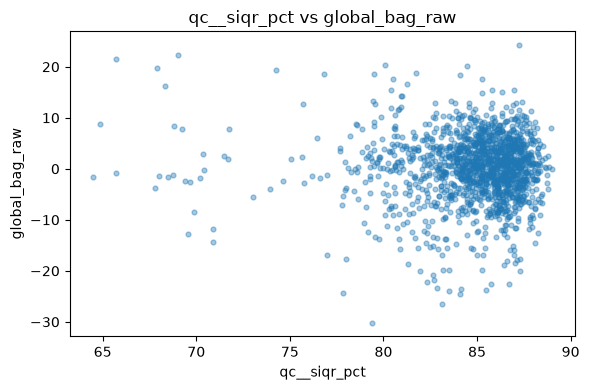

(                                                region  spearman_r  \
 420              Schaefer2018N400n7Tian2020S2__lAMY-lh   -0.321115   
 421              Schaefer2018N400n7Tian2020S2__lAMY-rh   -0.318020   
 115  Schaefer2018N400n7Tian2020S2__LH_SalVentAttn_F...   -0.304232   
 158         Schaefer2018N400n7Tian2020S2__LH_SomMot_34   -0.290675   
 160         Schaefer2018N400n7Tian2020S2__LH_SomMot_36   -0.284572   
 367         Schaefer2018N400n7Tian2020S2__RH_SomMot_40   -0.283226   
 355          Schaefer2018N400n7Tian2020S2__RH_SomMot_2   -0.281584   
 313  Schaefer2018N400n7Tian2020S2__RH_SalVentAttn_F...   -0.280690   
 223       Schaefer2018N400n7Tian2020S2__RH_Cont_PFCv_1   -0.272657   
 335         Schaefer2018N400n7Tian2020S2__RH_SomMot_11   -0.270639   
 423              Schaefer2018N400n7Tian2020S2__mAMY-rh   -0.265860   
 364         Schaefer2018N400n7Tian2020S2__RH_SomMot_38   -0.265054   
 114  Schaefer2018N400n7Tian2020S2__LH_SalVentAttn_F...   -0.264025   
 314  

In [ ]:
explore("qc__siqr_pct")  # a field with real coverage on the current (mostly-legacy) cohort

In [ ]:
list_features("phys").head(200)

,column,dtype,n_non_null
0,phys__seca__DOB,object,306
1,phys__seca__SMM (LA) value,object,306
2,phys__seca__Bioimpedance R (5 kHz)RA value,object,306
3,phys__seca__Total Body Water value,object,306
4,phys__seca__Extracellular water value,object,306
...,...,...,...
195,phys__seca__Bioimpedance R (30 kHz)TO value,object,285
196,phys__seca__Bioimpedance R (10 kHz)LL value,object,285
197,phys__seca__Bioimpedance |Xc| (1.5 kHz)RA value,object,285
198,phys__seca__Bioimpedance |Xc| (1.5 kHz)LL value,object,285


phys__seca__FFMI value vs global_bag_corrected (n=299)
  Pearson  r=0.011  p=0.851
  Spearman r=-0.039  p=0.5


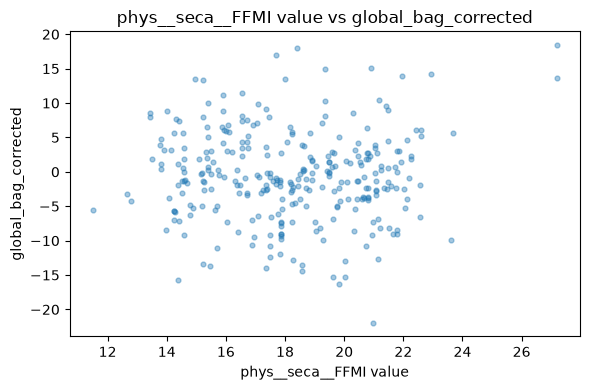

In [ ]:

ranking,sub = explore("phys__seca__FFMI value",bag_col="global_bag_corrected", top_n=1000)  # a field with real coverage on the current (mostly-legacy) cohort

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     global_bag_corrected   R-squared:                       0.014
Model:                              OLS   Adj. R-squared:                  0.009
Method:                   Least Squares   F-statistic:                     2.495
Date:                  Mon, 31 Aug 2026   Prob (F-statistic):             0.0591
Time:                          16:35:43   Log-Likelihood:                -1703.2
No. Observations:                   513   AIC:                             3414.
Df Residuals:                       509   BIC:                             3431.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.5751      1.040      1.515      0.130      -0.467       3.617
C(sex)[T.Male]    -0.4022      0.613     -0.656      0.512      -1.607       0.803
q__Salary      -9.306e-06   1.83e-05     -0.509      0.611   -4.52e-05    2.66e-05
age_true          -0.0723      0.029     -2.474      0.014      -0.130      -0.015
==============================================================================
Omnibus:                       69.029   Durbin-Watson:                   1.497
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              189.815
Skew:                           0.659   Prob(JB):                     6.05e-42
Kurtosis:                       5.673   Cond. No.                     8.42e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.42e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Text(0, 0.5, 'Global BAG (Corrected)')

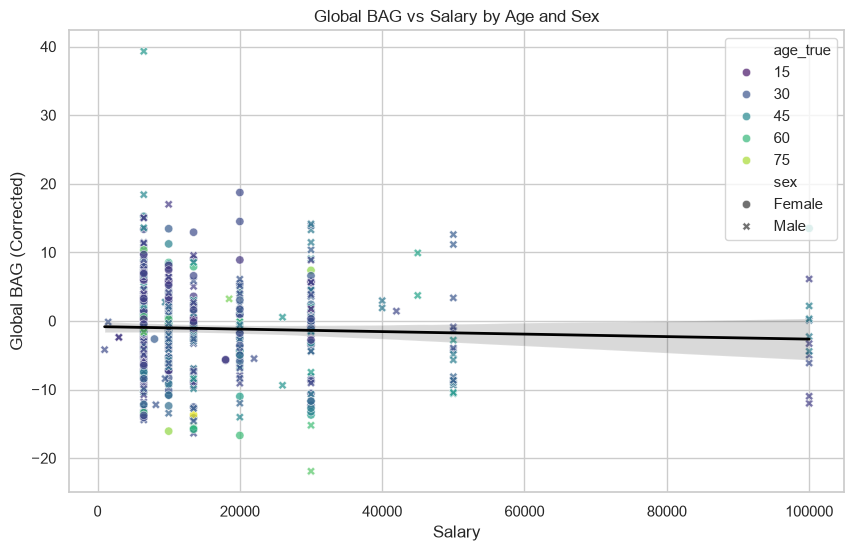

In [ ]:
import statsmodels.formula.api as smf

df = master[master["global_bag_corrected"].notna()]
# df = master.loc[sub.index]

df["q__Salary"] = pd.to_numeric(df["q__Salary"], errors="coerce")
model = smf.ols("global_bag_corrected ~ q__Salary+age_true + C(sex)", data=df).fit()
display(model.summary())

# plot global BAG vs phq9, colored by age and shaped by sex, with lines of best fit for each age group and sex, using seab
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="q__Salary", y="global_bag_corrected", hue="age_true", style="sex", palette="viridis", alpha=0.7)
sns.regplot(data=df, x="q__Salary", y="global_bag_corrected", scatter=False, color="black", line_kws={"linewidth": 2})
plt.title("Global BAG vs Salary by Age and Sex")
plt.xlabel("Salary")
plt.ylabel("Global BAG (Corrected)")

Text(0, 0.5, 'Global BAG (corrected)')

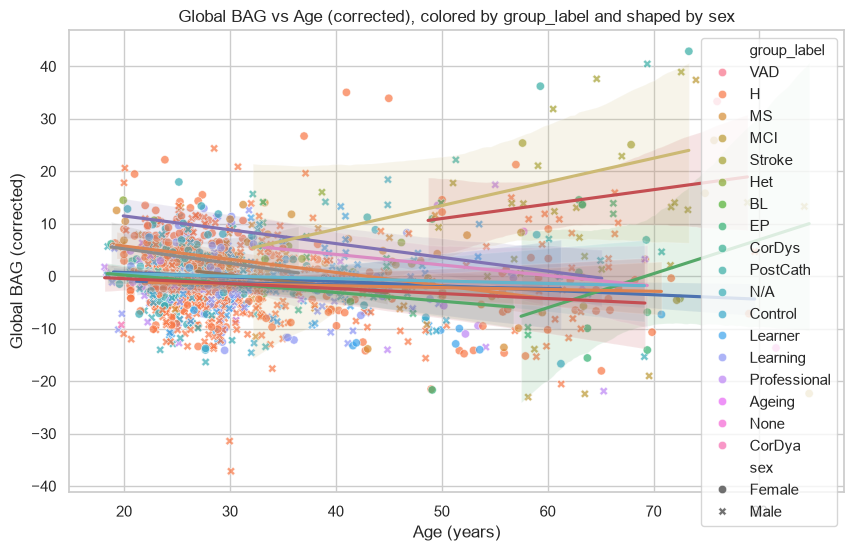

In [ ]:
import statsmodels.formula.api as smf

df = master[master["global_bag_corrected"].notna()]
# df = master.loc[sub.index]

model = smf.ols("global_bag_corrected ~ C(group_label)*age_true + C(sex)", data=df).fit()
model.summary()

# plot global BAG vs age_true, colored by group_label and shaped by sex
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=df, x="age_true", y="global_bag_corrected", hue="group_label", style="sex", alpha=0.7)
# add lines of best fit for each group_label and sex
for group in df["group_label"].unique():
    # for sex in df["sex"].unique():
    sub_df = df[(df["group_label"] == group)]
    if len(sub_df) < 2:
        continue
    sns.regplot(data=sub_df, x="age_true", y="global_bag_corrected", scatter=False, ax=ax, label=f"{group}")
plt.title("Global BAG vs Age (corrected), colored by group_label and shaped by sex")
plt.xlabel("Age (years)")
plt.ylabel("Global BAG (corrected)")

In [ ]:
df

,subject_key,session_id,age_true,global_bag_raw,global_bag_corrected,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_Cing_1,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_Cing_2,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_OFC_1,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_PFCl_1,region_bag_raw__Schaefer2018N400n7Tian2020S2__LH_Cont_PFCl_2,...,qc__siqr_grade,qc__ncr,qc__icr,qc__res_rms_mm,qc__contrast,qc__gmv_tiv_pct,qc__vol_abs_wmh,qc__vol_rel_wmh,days_from_beginning,year
0,200110171735,200110171735,76.000000,12.696930,33.309955,-24.095758,-38.240367,-25.156177,3.745504,-3.893197,...,C,0.055688,0.138079,1.385378,25.095505,32.060,9.900386,0.008462,40,2001
1,200602221251,200602221251,54.210000,-1.515588,5.643160,-13.109868,-17.769254,-6.055098,-11.388326,-7.185717,...,D+,0.047340,0.384624,1.385393,299.357147,42.173,2.609850,0.001720,1629,2006
2,200703091050,200703091050,30.000000,2.817818,2.548608,21.679403,2.823379,0.037703,-3.778929,0.219397,...,C-,0.045557,0.445150,1.075606,399.794312,49.601,16.073581,0.013326,2009,2007
3,200703110835,200703110835,35.000000,-9.105351,-11.961776,-1.328975,-7.702093,-1.467309,-5.942317,-10.408439,...,B-,0.035348,0.360339,1.075662,429.611938,50.225,1.406722,0.001011,2011,2007
4,200703230941,200703230941,48.000000,-1.798703,2.933544,-10.399128,-9.280077,-10.158044,-12.907363,-10.377505,...,C-,0.045723,0.372600,1.385355,413.164795,45.771,2.066572,0.001838,2023,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1527,S126914,202405161416,33.960000,-3.817243,-5.000445,-4.725983,-2.495258,-1.341019,8.348606,-0.180222,...,B+,0.026117,0.311407,0.898959,163.162567,48.502,0.929671,0.000710,8287,2024
1528,S128811,202504081510,39.019849,8.897462,14.148733,-10.317234,-0.417149,-8.116227,-1.790018,-3.402387,...,B,0.032763,0.417673,0.898959,162.998108,42.409,2.266754,0.001200,8614,2025
1529,S130253,202203291136,63.490000,-0.441872,10.286826,-28.297190,-26.331355,-21.872857,-15.284109,-21.135718,...,B,0.030530,0.409810,0.898958,153.048309,40.528,2.084920,0.001291,7508,2022
1530,S132089,202408191022,24.970000,6.730944,6.111813,7.863969,8.806407,8.000900,5.373265,0.832891,...,B+,0.028325,0.354505,0.898959,159.090851,46.958,0.919085,0.000631,8382,2024


In [ ]:
# FDR correction
from statsmodels.stats.multitest import multipletests

ranking,sub = explore("group_label",bag_col="global_bag_corrected", specific_groups=["H", "MCI", "Stroke"], top_n=1000)  # a field with real coverage on the current (mostly-legacy) cohort

_, p_values, _, _ = multipletests(ranking["p"], alpha=0.05, method="fdr_bh")
ranking["p_fdr"] = p_values


In [ ]:
from scipy import stats

group1 = sub[sub["group_label"] == "H"]["global_bag_corrected"]
group2 = sub[sub["group_label"] == "Stroke"]["global_bag_corrected"]
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's t-test
print(f"Welch's t-test: t-statistic = {t_stat:.3f}, p-value = {p_value:.3g}")

KeyError: 'group_label'

Text(0, 0.5, 'Density')

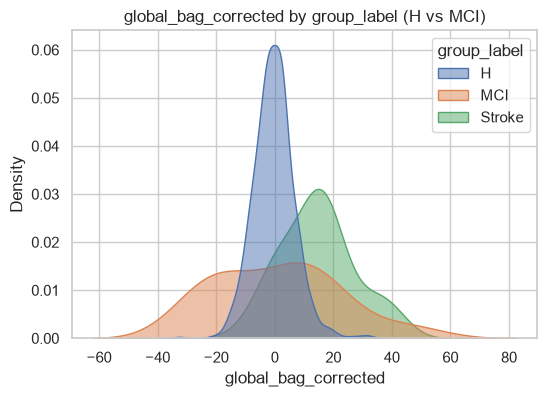

In [ ]:
import seaborn as sns
fig, ax = plt.subplots(1,1, figsize=(6, 4))
# ax = sns.kdeplot(data=sub[sub["group_label"].isin(["H", "MCI"])], x="global_bag_corrected", hue="group_label", fill=True, common_norm=False, alpha=0.5, ax=ax)
ax = sns.kdeplot(data=sub, x="global_bag_corrected", hue="group_label", fill=True, common_norm=False, alpha=0.5, ax=ax)
ax.set_title("global_bag_corrected by group_label (H vs MCI)")
ax.set_xlabel("global_bag_corrected")
ax.set_ylabel("Density")




<Axes: xlabel='year', ylabel='global_bag_corrected'>

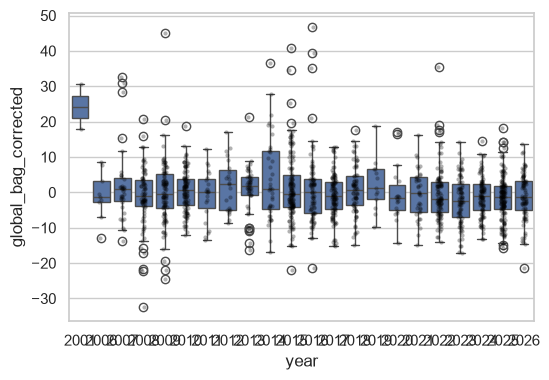

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6, 4))
sns.boxplot(data=master, x="year", y="global_bag_corrected", ax=ax)
sns.stripplot(data=master, x="year", y="global_bag_corrected", ax=ax, color='black', alpha=0.3, size=3)


## 8. Region-wise results on the brain (yabplot)

Visualizes the most recent `ranking` DataFrame (region + `spearman_r`/`F` column) from
`explore()` on the actual cortical/subcortical surfaces, via the maintainer's own
[yabplot](https://github.com/GalKepler/yabplot) package (`config/local.yaml`'s
`paths.yabplot_repo`, not on PyPI — `uv pip install -e <that path>` to enable this cell).

Region names are `Schaefer2018N400n7Tian2020S2__<region>` (see Phase 2's 2026-08-21/24
notes): cortical regions map onto yabplot's `schaefer400` atlas one-to-one (after
restoring the `7Networks_` prefix yabplot expects). Subcortical regions are Tian
**scale II** (32 regions) — plotted via a custom atlas of per-region meshes
(`config/local.yaml`'s `paths.yabplot_tian_s2_atlas`) whose 32 filenames match our
region names exactly, no yabplot built-in atlas needed.

In [ ]:
ranking.sort_values("p_fdr").head(20)

,region,F,p,n,p_fdr
407,Schaefer2018N400n7Tian2020S2__THA-DP-rh,26.865610,3.073897e-58,1258,1.327924e-55
366,Schaefer2018N400n7Tian2020S2__RH_SomMot_3,25.588607,1.677264e-55,1258,3.622889e-53
344,Schaefer2018N400n7Tian2020S2__RH_SomMot_1,25.030253,2.684990e-54,1258,3.866386e-52
313,Schaefer2018N400n7Tian2020S2__RH_SalVentAttn_F...,24.852039,6.521164e-54,1258,7.042858e-52
371,Schaefer2018N400n7Tian2020S2__RH_SomMot_7,23.509202,5.413145e-51,1258,4.676958e-49
315,Schaefer2018N400n7Tian2020S2__RH_SalVentAttn_F...,23.151710,3.274398e-50,1258,2.357566e-48
153,Schaefer2018N400n7Tian2020S2__LH_SomMot_2,22.948412,9.130778e-50,1258,5.634994e-48
312,Schaefer2018N400n7Tian2020S2__RH_SalVentAttn_F...,22.245910,3.193494e-48,1258,1.724487e-46
142,Schaefer2018N400n7Tian2020S2__LH_SomMot_1,22.186164,4.324124e-48,1258,2.075579e-46
223,Schaefer2018N400n7Tian2020S2__RH_Cont_PFCv_1,22.028304,9.637175e-48,1258,4.163260e-46


2026-08-30 21:31:20.179 (   8.161s) [    7C8FA7A57740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


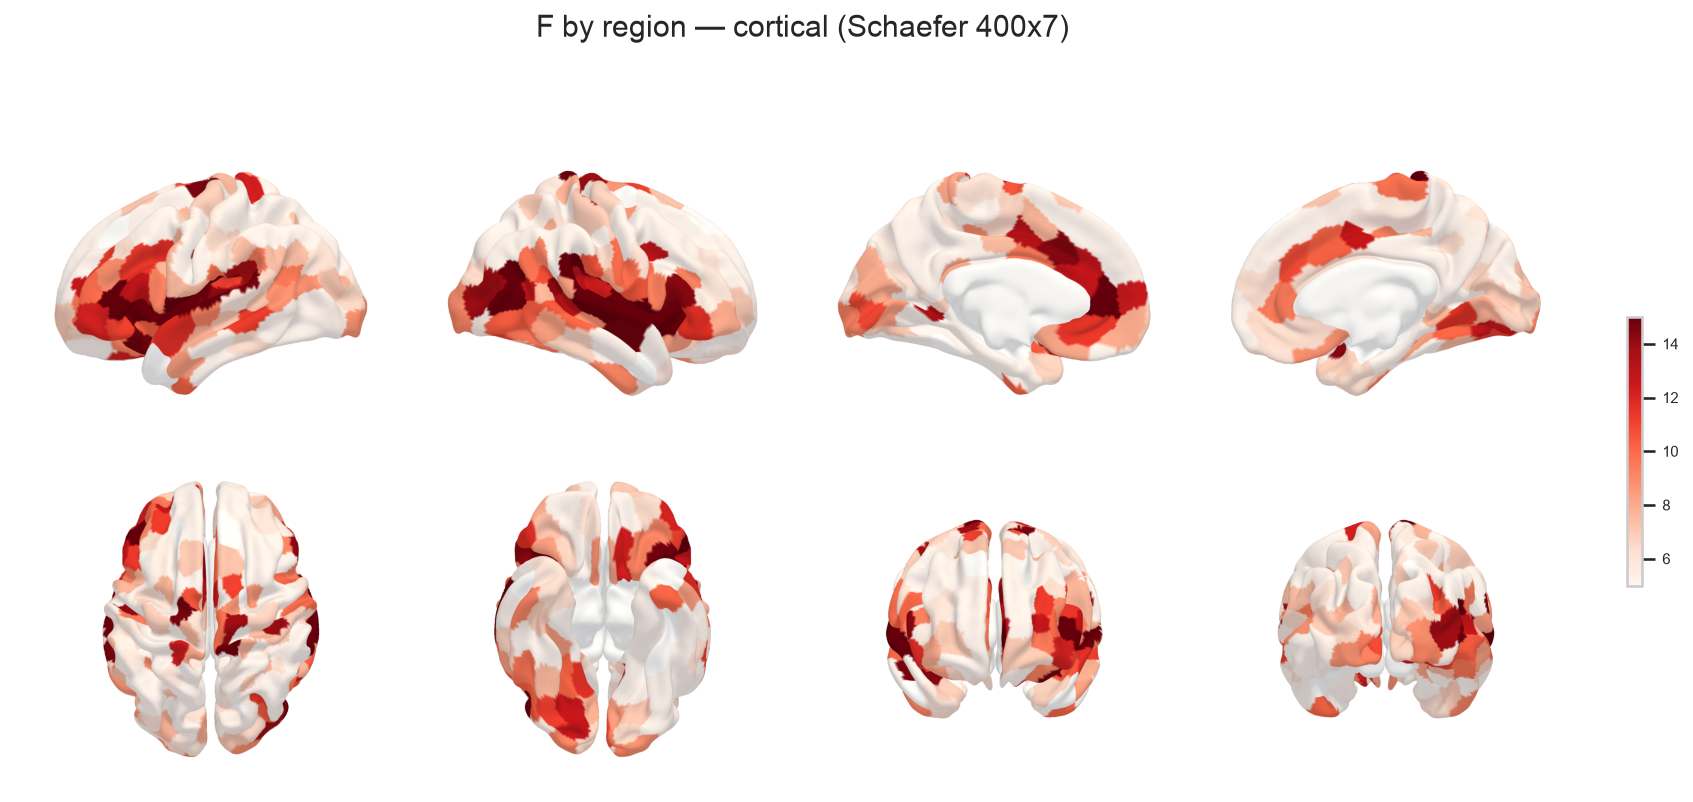

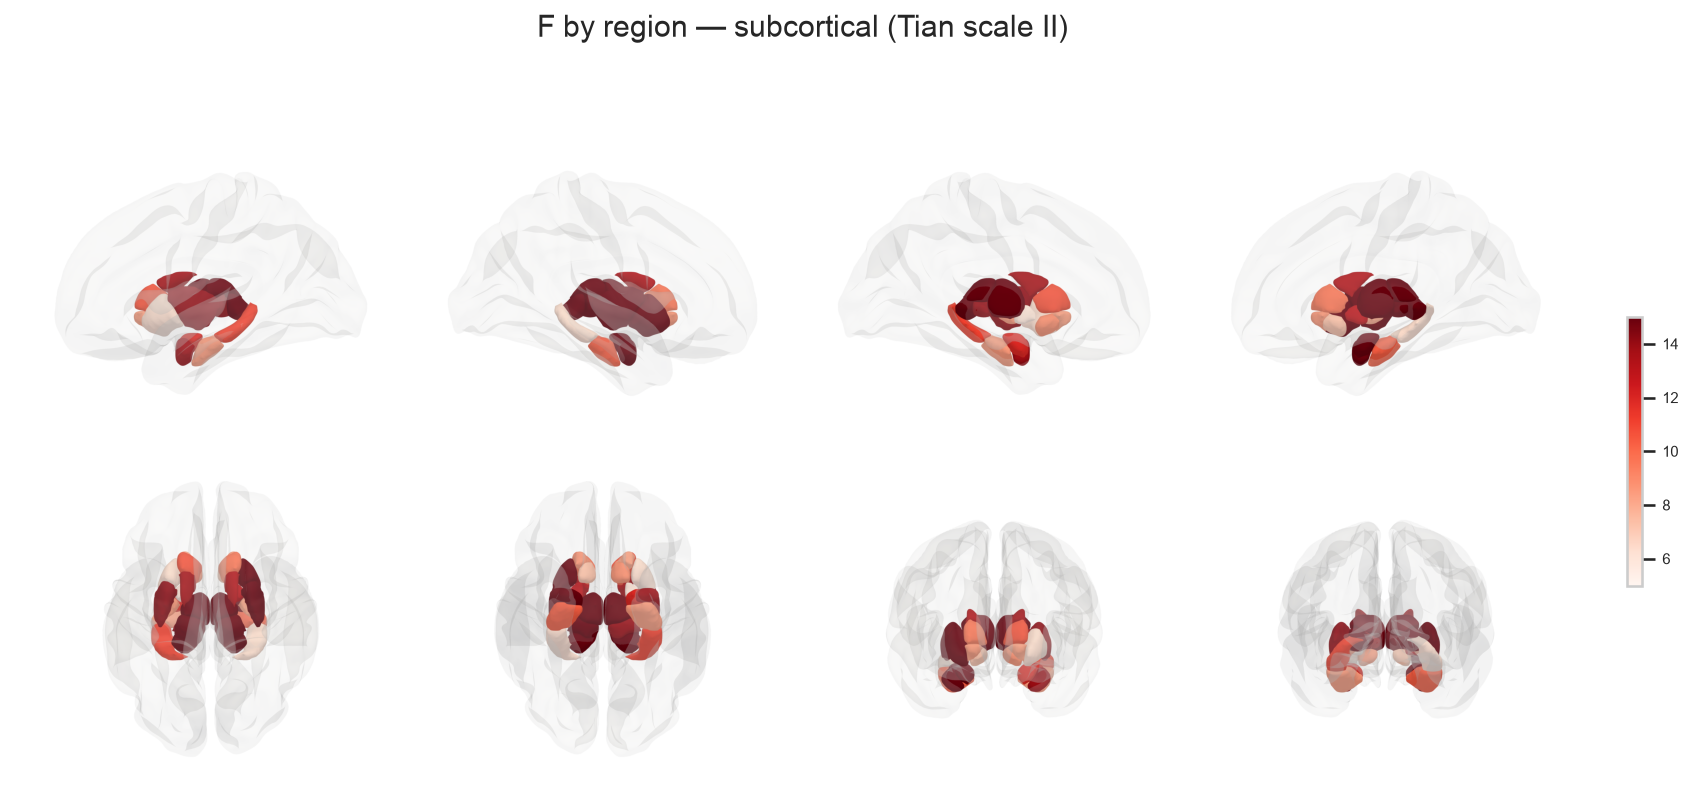

In [ ]:
import yabplot

value_col = "spearman_r" if "spearman_r" in ranking.columns else "F"
ranking[value_col+"_sig"] = ranking[value_col].where(ranking["p_fdr"] < 0.05, np.nan)
region_values = {col.split("__", 1)[1]: val for col, val in zip(ranking["region"], ranking[value_col+"_sig"])}

cortical_vals = {f"7Networks_{r}": v for r, v in region_values.items() if r.startswith(("LH_", "RH_"))}
subcortical_vals = {r: v for r, v in region_values.items() if not r.startswith(("LH_", "RH_"))}

ax_c = yabplot.plot_cortical(cortical_vals, atlas="schaefer400", cmap="Reds", vminmax= (5, 15))
ax_c.figure.suptitle(f"{value_col} by region — cortical (Schaefer 400x7)")
plt.show()

ax_s = yabplot.plot_subcortical(
    subcortical_vals, custom_atlas_path=str(get_path("yabplot_tian_s2_atlas")), cmap="Reds", vminmax= (5, 15)
)
ax_s.figure.suptitle(f"{value_col} by region — subcortical (Tian scale II)")
plt.show()

In [ ]:
yabplot.plot_cortical?

Signature:
yabplot.plot_cortical(
    data=None,
    atlas=None,
    custom_atlas_path=None,
    ax=None,
    cbar_kwargs=None,
    views=None,
    layout=None,
    bmesh='midthickness',
    figsize=None,
    cmap='coolwarm',
    vminmax=[None, None],
    nan_color=(1.0, 1.0, 1.0),
    style='default',
    zoom=1.2,
    proc_vertices=None,
    display_type='matplotlib',
    export_path=None,
    contours=False,
)
Docstring:
Visualize data on the cortical surface using a specified atlas.

This function maps scalar values to cortical regions (parcellations) on a standard
surface mesh (Conte69). It supports both pre-existing atlases and custom local atlases.

Parameters
----------
data : dict, list, numpy.ndarray, optional
    Data to map onto the cortex.
    If dict: Keys must match region names in the atlas (see `yabplot.get_atlas_regions`).
    If array/list: Must match the exact length and order of the atlas regions.
    If None: The atlas is plotted with categorical colors (one color